# Final Analysis: Baseline vs Static GRL vs Standard Dynamic GRL vs Final Dynamic

This notebook **does not retrain any model**. It reads the completed seed-level artefacts saved by the final model notebooks, produces multi-seed summaries, Female/Male appendix tables, **10,000-replicate** sex-stratified patient-cluster bootstrap confidence intervals, paired bootstrap confidence intervals for model differences, empirical two-sided p-values, and Holm–Bonferroni / Benjamini–Hochberg multiplicity corrections.

**Do not change the saved thresholds.** Each bootstrap replicate uses the frozen, seed-specific thresholds selected on the complete validation set.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score, accuracy_score
from IPython.display import display

from r50_multilabel_final_common import (
    build_label_fairness_summary,
    compute_test_metrics_by_group,
    summarise_overall_fairness,
)

# ------------------------------------------------------------------
# Fixed final-analysis protocol
# ------------------------------------------------------------------
RESULTS_DIR = Path("results")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

FINAL_SEEDS = [42, 123, 2026]
N_BOOTSTRAP = 10000
BOOTSTRAP_RANDOM_SEED = 202606
RUN_BOOTSTRAP = True

MODEL_SPECS = {
    "Baseline": {
        "model_variant": "r50_baseline",
        "prefix": "r50_baseline_final_seed",
        "adversarial": False,
        "sex_head_comparable": False,
    },
    "Static GRL": {
        "model_variant": "r50_static_grl",
        "prefix": "r50_static_grl_seed",
        "adversarial": True,
        "sex_head_comparable": True,
    },
    "Standard Dynamic GRL": {
        "model_variant": "r50_dynamic_grl",
        "prefix": "r50_dynamic_grl_seed",
        "adversarial": True,
        "sex_head_comparable": True,
    },
    "Final Dynamic": {
        "model_variant": "r50_dynamic_eo_gradnorm_common_epoch_v2",
        "prefix": "r50_dynamic_eo_gradnorm_common_epoch_v2_seed",
        "adversarial": True,
        # The final adversary is EO-conditioned and is not directly comparable
        # with the single unconditional sex heads used by Static/Standard Dynamic.
        "sex_head_comparable": False,
    },
}

PRIMARY_METRICS = [
    "macro_AUROC",
    "macro_AUPRC",
    "mean_FNR_gap",
    "mean_FPR_gap",
    "mean_Equalized_Odds_gap",
    "mean_Worst_group_Recall",
    "mean_AUROC_gap",
]

print("Results directory:", RESULTS_DIR.resolve())
print("Seeds:", FINAL_SEEDS)
print("Bootstrap replicates:", N_BOOTSTRAP)


Results directory: /Users/shuu/Desktop/Msc Program/results
Seeds: [42, 123, 2026]
Bootstrap replicates: 10000


In [2]:
# ------------------------------------------------------------------
# Load all completed seed-level artefacts and validate their protocol
# ------------------------------------------------------------------
def _require(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing required artefact: {path}")
    return path


def load_seed_run(model_name: str, spec: dict, seed: int) -> dict:
    prefix = RESULTS_DIR / f"{spec['prefix']}{seed}"
    required = {
        "overall": Path(f"{prefix}_overall_results.csv"),
        "label": Path(f"{prefix}_test_label_metrics.csv"),
        "subgroup": Path(f"{prefix}_subgroup_metrics.csv"),
        "fairness": Path(f"{prefix}_label_fairness_summary.csv"),
        "thresholds": Path(f"{prefix}_thresholds.csv"),
        "predictions": Path(f"{prefix}_test_predictions.npz"),
        "config": Path(f"{prefix}_run_config.json"),
    }
    for item in required.values():
        _require(item)

    archive = np.load(required["predictions"], allow_pickle=False)
    with open(required["config"], "r", encoding="utf-8") as f:
        run_config = json.load(f)

    labels = archive["labels"].astype(str).tolist()
    run = {
        "model": model_name,
        "model_variant": spec["model_variant"],
        "seed": int(seed),
        "prefix": str(prefix),
        "overall": pd.read_csv(required["overall"]),
        "label_metrics": pd.read_csv(required["label"]),
        "subgroup_metrics": pd.read_csv(required["subgroup"]),
        "label_fairness": pd.read_csv(required["fairness"]),
        "thresholds_df": pd.read_csv(required["thresholds"]),
        "probs": archive["probs"],
        "targets": archive["targets"],
        "sexes": archive["sexes"].astype(int),
        "patient_ids": archive["patient_ids"].astype(str),
        "image_indices": archive["image_indices"].astype(str),
        "labels": labels,
        "run_config": run_config,
        "sex_head_comparable": bool(spec.get("sex_head_comparable", False)),
    }
    if spec["adversarial"]:
        if "sex_probs" not in archive:
            raise KeyError(f"{prefix} should contain sex_probs for an adversarial model.")
        run["sex_probs"] = archive["sex_probs"]
    return run


runs = []
for model_name, spec in MODEL_SPECS.items():
    for seed in FINAL_SEEDS:
        runs.append(load_seed_run(model_name, spec, seed))

# All model/seed archives must correspond to the identical immutable test split.
reference = runs[0]
for run in runs[1:]:
    if run["labels"] != reference["labels"]:
        raise ValueError(f"Different label order in {run['model']} seed {run['seed']}.")
    for key in ["targets", "sexes", "patient_ids", "image_indices"]:
        if not np.array_equal(run[key], reference[key]):
            raise ValueError(
                f"Test split/order mismatch in {run['model']} seed {run['seed']} for {key}."
            )

# Confirm every threshold table uses validation-only selection.
for run in runs:
    expected = {"label", "selected_threshold", "selection_population"}
    if not expected.issubset(run["thresholds_df"].columns):
        raise KeyError(f"Threshold table malformed for {run['model']} seed {run['seed']}.")
    populations = set(run["thresholds_df"]["selection_population"].astype(str))
    if populations != {"complete_validation_set"}:
        raise ValueError(
            f"Unexpected threshold-selection population for {run['model']} seed {run['seed']}: {populations}"
        )

print(f"Loaded {len(runs)} completed runs.")
print("Labels:", reference["labels"])
print("Fixed test images:", len(reference["targets"]))
print("Fixed test patients:", len(np.unique(reference["patient_ids"])))


Loaded 12 completed runs.
Labels: ['Infiltration', 'Effusion', 'Atelectasis', 'Nodule', 'Mass', 'Pneumothorax', 'Consolidation']
Fixed test images: 22294
Fixed test patients: 6161


In [3]:
# ------------------------------------------------------------------
# Multi-seed summaries and appendix tables
# ------------------------------------------------------------------
def mean_std_table(df: pd.DataFrame, group_cols, metric_cols) -> pd.DataFrame:
    metric_cols = [c for c in metric_cols if c in df.columns]
    work = df[list(group_cols) + metric_cols].copy()
    for col in metric_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")
    grouped = work.groupby(list(group_cols), dropna=False)[metric_cols]
    return pd.concat(
        [
            grouped.mean().add_suffix("_mean"),
            grouped.std(ddof=1).add_suffix("_std"),
            grouped.count().add_suffix("_n_seeds"),
        ],
        axis=1,
    ).reset_index()


def standardise_overall_row(run: dict) -> pd.DataFrame:
    """Map model-specific saved fields onto one final-analysis schema."""
    frame = run["overall"].copy()
    frame["model"] = run["model"]

    # Common utility names.
    frame = frame.rename(
        columns={
            "test_macro_auroc": "macro_AUROC",
            "test_macro_auprc": "macro_AUPRC",
            "test_sex_auroc": "sex_head_AUROC",
            "test_sex_accuracy": "sex_head_accuracy",
        }
    )

    # The final dynamic method selects one common epoch across seeds, whereas
    # the earlier models save per-seed best_epoch fields. Standardise only for
    # descriptive reporting; this does not alter model selection.
    if "selected_common_epoch" in frame.columns and "best_epoch" not in frame.columns:
        frame["best_epoch"] = frame["selected_common_epoch"]
    if "selected_seed_val_macro_auroc" in frame.columns and "best_val_macro_auroc" not in frame.columns:
        frame["best_val_macro_auroc"] = frame["selected_seed_val_macro_auroc"]

    # Do not report the EO-conditioned adversary score as if it were directly
    # comparable to the unconditional sex-head AUROC of the earlier GRL models.
    if not run.get("sex_head_comparable", False):
        frame["sex_head_AUROC"] = np.nan
        frame["sex_head_accuracy"] = np.nan

    return frame


overall_seed = pd.concat([standardise_overall_row(run) for run in runs], ignore_index=True)
label_seed = pd.concat([run["label_metrics"].assign(model=run["model"]) for run in runs], ignore_index=True)
subgroup_seed = pd.concat([run["subgroup_metrics"].assign(model=run["model"]) for run in runs], ignore_index=True)
fairness_seed = pd.concat([run["label_fairness"].assign(model=run["model"]) for run in runs], ignore_index=True)

main_summary = mean_std_table(
    overall_seed,
    group_cols=["model"],
    metric_cols=[
        "best_epoch", "best_val_macro_auroc", "macro_AUROC", "macro_AUPRC",
        "mean_FNR_gap", "mean_FPR_gap", "mean_Equalized_Odds_gap",
        "mean_Worst_group_Recall", "mean_AUROC_gap",
        "sex_head_AUROC", "sex_head_accuracy",
    ],
)
label_summary = mean_std_table(
    label_seed, ["model", "label"], ["AUROC", "AUPRC", "TPR", "FNR", "TNR", "FPR"]
)
subgroup_summary = mean_std_table(
    subgroup_seed,
    ["model", "group", "label"],
    ["support", "positive_support", "negative_support", "AUROC", "AUPRC", "TPR", "Recall", "FNR", "TNR", "Specificity", "FPR"],
)
fairness_label_summary = mean_std_table(
    fairness_seed,
    ["model", "label"],
    ["FNR_gap", "FPR_gap", "Equalized_Odds_gap", "AUROC_gap", "AUPRC_gap", "Worst_group_Recall", "Worst_group_AUROC"],
)

main_display = main_summary.copy()
for metric in [
    "macro_AUROC", "macro_AUPRC", "mean_FNR_gap", "mean_FPR_gap",
    "mean_Equalized_Odds_gap", "mean_Worst_group_Recall", "mean_AUROC_gap",
    "sex_head_AUROC", "sex_head_accuracy",
]:
    main_display[f"{metric} (mean ± std)"] = main_display.apply(
        lambda row: "N/A" if pd.isna(row[f"{metric}_mean"]) else f"{row[f'{metric}_mean']:.4f} ± {row[f'{metric}_std']:.4f}",
        axis=1,
    )

overall_seed.to_csv(RESULTS_DIR / "final_analysis_seed_level_overall.csv", index=False)
label_seed.to_csv(RESULTS_DIR / "final_analysis_seed_level_per_label.csv", index=False)
subgroup_seed.to_csv(RESULTS_DIR / "final_analysis_seed_level_subgroup.csv", index=False)
fairness_seed.to_csv(RESULTS_DIR / "final_analysis_seed_level_label_fairness.csv", index=False)
main_summary.to_csv(RESULTS_DIR / "final_analysis_main_mean_std.csv", index=False)
label_summary.to_csv(RESULTS_DIR / "final_analysis_per_label_mean_std.csv", index=False)
subgroup_summary.to_csv(RESULTS_DIR / "final_analysis_female_male_per_label_mean_std.csv", index=False)
fairness_label_summary.to_csv(RESULTS_DIR / "final_analysis_per_label_fairness_mean_std.csv", index=False)
main_display.to_csv(RESULTS_DIR / "final_analysis_main_manuscript_table.csv", index=False)

print("Main multi-seed summary")
display(main_display[[
    "model", "macro_AUROC (mean ± std)", "macro_AUPRC (mean ± std)",
    "mean_FNR_gap (mean ± std)", "mean_FPR_gap (mean ± std)",
    "mean_Equalized_Odds_gap (mean ± std)", "mean_Worst_group_Recall (mean ± std)",
    "mean_AUROC_gap (mean ± std)", "sex_head_AUROC (mean ± std)",
]])


Main multi-seed summary


,model,macro_AUROC (mean ± std),macro_AUPRC (mean ± std),mean_FNR_gap (mean ± std),mean_FPR_gap (mean ± std),mean_Equalized_Odds_gap (mean ± std),mean_Worst_group_Recall (mean ± std),mean_AUROC_gap (mean ± std),sex_head_AUROC (mean ± std)
0,Baseline,0.8091 ± 0.0029,0.3072 ± 0.0027,0.0491 ± 0.0073,0.0183 ± 0.0036,0.0494 ± 0.0070,0.4429 ± 0.0143,0.0142 ± 0.0019,N/A
1,Final Dynamic,0.8113 ± 0.0017,0.3114 ± 0.0014,0.0288 ± 0.0032,0.0102 ± 0.0020,0.0302 ± 0.0028,0.4622 ± 0.0151,0.0127 ± 0.0006,N/A
2,Standard Dynamic GRL,0.8077 ± 0.0016,0.3050 ± 0.0034,0.0453 ± 0.0127,0.0146 ± 0.0056,0.0454 ± 0.0128,0.4387 ± 0.0118,0.0132 ± 0.0014,0.5559 ± 0.0077
3,Static GRL,0.8098 ± 0.0006,0.3067 ± 0.0031,0.0365 ± 0.0020,0.0140 ± 0.0012,0.0374 ± 0.0032,0.4518 ± 0.0079,0.0124 ± 0.0008,0.5531 ± 0.0250


In [4]:
# ------------------------------------------------------------------
# Sex-stratified patient-cluster bootstrap CI + paired model differences
# ------------------------------------------------------------------
def safe_auroc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    return np.nan if np.unique(y_true).size < 2 else float(roc_auc_score(y_true, y_prob))


def safe_auprc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    return np.nan if y_true.sum() == 0 else float(average_precision_score(y_true, y_prob))


def metrics_from_indices(run: dict, indices: np.ndarray) -> dict:
    probs = run["probs"][indices]
    targets = run["targets"][indices]
    sexes = run["sexes"][indices]
    labels = run["labels"]

    overall_metrics, subgroup_metrics = compute_test_metrics_by_group(
        probs=probs,
        targets=targets,
        sexes=sexes,
        labels=labels,
        thresholds_df=run["thresholds_df"],
    )
    label_fairness = build_label_fairness_summary(
        overall_metrics=overall_metrics,
        subgroup_metrics=subgroup_metrics,
        model_name="bootstrap",
    )
    summary = summarise_overall_fairness(label_fairness)
    result = {
        "macro_AUROC": float(np.nanmean([safe_auroc(targets[:, i], probs[:, i]) for i in range(len(labels))])),
        "macro_AUPRC": float(np.nanmean([safe_auprc(targets[:, i], probs[:, i]) for i in range(len(labels))])),
        **summary,
    }
    if "sex_probs" in run and run.get("sex_head_comparable", False):
        sex_probs = run["sex_probs"][indices]
        result["sex_head_AUROC"] = safe_auroc(sexes, sex_probs)
        result["sex_head_accuracy"] = float(accuracy_score(sexes, (sex_probs >= 0.5).astype(int)))
    return result


def make_sex_stratified_patient_bootstrap_indices(sexes, patient_ids, rng):
    """Resample patients, not images; retain Female and Male groups in every replicate."""
    sexes = np.asarray(sexes).astype(int)
    patient_ids = np.asarray(patient_ids).astype(str)
    unique_patients, inverse = np.unique(patient_ids, return_inverse=True)
    patient_image_indices = [np.flatnonzero(inverse == p) for p in range(len(unique_patients))]
    patient_sex = np.empty(len(unique_patients), dtype=int)

    for p, image_indices in enumerate(patient_image_indices):
        values = np.unique(sexes[image_indices])
        if len(values) != 1:
            raise ValueError(f"Patient {unique_patients[p]} has inconsistent sex metadata.")
        patient_sex[p] = values[0]

    chunks = []
    for sex_value in (0, 1):
        patient_positions = np.flatnonzero(patient_sex == sex_value)
        if len(patient_positions) == 0:
            raise ValueError("Both Female and Male patient clusters are required.")
        sampled_positions = rng.choice(patient_positions, size=len(patient_positions), replace=True)
        chunks.extend(patient_image_indices[p] for p in sampled_positions)
    return np.concatenate(chunks)


if RUN_BOOTSTRAP:
    runs_by_model = {name: [run for run in runs if run["model"] == name] for name in MODEL_SPECS}
    rng = np.random.default_rng(BOOTSTRAP_RANDOM_SEED)
    model_distribution_rows = []
    paired_distribution_rows = []

    progress_every = max(1, N_BOOTSTRAP // 20)  # ~20 progress updates
    for iteration in range(N_BOOTSTRAP):
        indices = make_sex_stratified_patient_bootstrap_indices(reference["sexes"], reference["patient_ids"], rng)
        replicate_means = {}

        for model_name, model_runs in runs_by_model.items():
            seed_metrics = [metrics_from_indices(run, indices) for run in model_runs]
            means = pd.DataFrame(seed_metrics).mean(numeric_only=True).to_dict()
            replicate_means[model_name] = means
            model_distribution_rows.append({
                "bootstrap_iteration": iteration,
                "model": model_name,
                "n_images_in_resample": int(len(indices)),
                "n_seeds_aggregated": len(model_runs),
                **means,
            })

        for candidate, reference_model in [
            ("Static GRL", "Baseline"),
            ("Standard Dynamic GRL", "Baseline"),
            ("Standard Dynamic GRL", "Static GRL"),
            ("Final Dynamic", "Baseline"),
            ("Final Dynamic", "Static GRL"),
            ("Final Dynamic", "Standard Dynamic GRL"),
        ]:
            paired_distribution_rows.append({
                "bootstrap_iteration": iteration,
                "comparison": f"{candidate} - {reference_model}",
                **{metric: replicate_means[candidate].get(metric, np.nan) - replicate_means[reference_model].get(metric, np.nan) for metric in PRIMARY_METRICS},
            })

        if (iteration + 1) % progress_every == 0 or iteration == 0:
            print(f"Completed {iteration + 1}/{N_BOOTSTRAP} bootstrap replicates")

    bootstrap_distribution = pd.DataFrame(model_distribution_rows)
    paired_distribution = pd.DataFrame(paired_distribution_rows)

    point_estimates = overall_seed.groupby("model", as_index=True)[PRIMARY_METRICS + ["sex_head_AUROC", "sex_head_accuracy"]].mean()

    ci_rows = []
    for model_name in MODEL_SPECS:
        model_boot = bootstrap_distribution[bootstrap_distribution["model"] == model_name]
        for metric in PRIMARY_METRICS + ["sex_head_AUROC", "sex_head_accuracy"]:
            values = model_boot[metric].dropna().to_numpy(dtype=float) if metric in model_boot else np.array([])
            point = point_estimates.loc[model_name, metric] if metric in point_estimates.columns else np.nan
            lower, upper = (np.nan, np.nan) if len(values) == 0 or pd.isna(point) else np.percentile(values, [2.5, 97.5])
            ci_rows.append({
                "model": model_name,
                "metric": metric,
                "point_estimate_mean_across_seeds": point,
                "ci_level": 0.95,
                "ci_lower": lower,
                "ci_upper": upper,
                "n_bootstrap": N_BOOTSTRAP,
                "resampling_unit": "Patient ID cluster, stratified by sex",
                "threshold_policy": "Frozen seed-specific thresholds selected on complete validation set",
            })
    bootstrap_ci = pd.DataFrame(ci_rows)

    diff_rows = []
    for candidate, reference_model in [
        ("Static GRL", "Baseline"),
        ("Standard Dynamic GRL", "Baseline"),
        ("Standard Dynamic GRL", "Static GRL"),
        ("Final Dynamic", "Baseline"),
        ("Final Dynamic", "Static GRL"),
        ("Final Dynamic", "Standard Dynamic GRL"),
    ]:
        comparison = f"{candidate} - {reference_model}"
        comparison_distribution = paired_distribution[paired_distribution["comparison"] == comparison]
        for metric in PRIMARY_METRICS:
            values = comparison_distribution[metric].dropna().to_numpy(dtype=float)
            point = point_estimates.loc[candidate, metric] - point_estimates.loc[reference_model, metric]
            lower, upper = np.percentile(values, [2.5, 97.5])
            diff_rows.append({
                "comparison": comparison,
                "metric": metric,
                "point_difference_candidate_minus_reference": point,
                "ci_level": 0.95,
                "ci_lower": lower,
                "ci_upper": upper,
                "zero_in_ci": bool(lower <= 0 <= upper),
                "n_bootstrap": N_BOOTSTRAP,
                "resampling_unit": "Paired Patient ID cluster bootstrap, stratified by sex",
            })
    paired_difference_ci = pd.DataFrame(diff_rows)

    bootstrap_distribution.to_csv(RESULTS_DIR / "final_analysis_patient_cluster_bootstrap_distribution.csv", index=False)
    paired_distribution.to_csv(RESULTS_DIR / "final_analysis_paired_difference_bootstrap_distribution.csv", index=False)
    bootstrap_ci.to_csv(RESULTS_DIR / "final_analysis_patient_cluster_bootstrap_95ci.csv", index=False)
    paired_difference_ci.to_csv(RESULTS_DIR / "final_analysis_paired_model_difference_bootstrap_95ci.csv", index=False)

    print("\n95% patient-cluster bootstrap CIs")
    display(bootstrap_ci)
    print("\nPaired model-difference 95% CIs")
    display(paired_difference_ci)
else:
    print("Bootstrap disabled. Set RUN_BOOTSTRAP = True to calculate 95% CIs.")


Completed 1/10000 bootstrap replicates
Completed 500/10000 bootstrap replicates
Completed 1000/10000 bootstrap replicates
Completed 1500/10000 bootstrap replicates
Completed 2000/10000 bootstrap replicates
Completed 2500/10000 bootstrap replicates
Completed 3000/10000 bootstrap replicates
Completed 3500/10000 bootstrap replicates
Completed 4000/10000 bootstrap replicates
Completed 4500/10000 bootstrap replicates
Completed 5000/10000 bootstrap replicates
Completed 5500/10000 bootstrap replicates
Completed 6000/10000 bootstrap replicates
Completed 6500/10000 bootstrap replicates
Completed 7000/10000 bootstrap replicates
Completed 7500/10000 bootstrap replicates
Completed 8000/10000 bootstrap replicates
Completed 8500/10000 bootstrap replicates
Completed 9000/10000 bootstrap replicates
Completed 9500/10000 bootstrap replicates
Completed 10000/10000 bootstrap replicates

95% patient-cluster bootstrap CIs


,model,metric,point_estimate_mean_across_seeds,ci_level,ci_lower,ci_upper,n_bootstrap,resampling_unit,threshold_policy
0,Baseline,macro_AUROC,0.809136,0.95,0.803560,0.814478,10000,"Patient ID cluster, stratified by sex",Frozen seed-specific thresholds selected on co...
1,Baseline,macro_AUPRC,0.307159,0.95,0.295953,0.319291,10000,"Patient ID cluster, stratified by sex",Frozen seed-specific thresholds selected on co...
2,Baseline,mean_FNR_gap,0.049146,0.95,0.036210,0.087918,10000,"Patient ID cluster, stratified by sex",Frozen seed-specific thresholds selected on co...
3,Baseline,mean_FPR_gap,0.018262,0.95,0.013428,0.029326,10000,"Patient ID cluster, stratified by sex",Frozen seed-specific thresholds selected on co...
4,Baseline,mean_Equalized_Odds_gap,0.049360,0.95,0.038623,0.088661,10000,"Patient ID cluster, stratified by sex",Frozen seed-specific thresholds selected on co...
5,Baseline,mean_Worst_group_Recall,0.442895,0.95,0.414071,0.457829,10000,"Patient ID cluster, stratified by sex",Frozen seed-specific thresholds selected on co...
6,Baseline,mean_AUROC_gap,0.014211,0.95,0.011269,0.027730,10000,"Patient ID cluster, stratified by sex",Frozen seed-specific thresholds selected on co...
7,Baseline,sex_head_AUROC,NaN,0.95,NaN,NaN,10000,"Patient ID cluster, stratified by sex",Frozen seed-specific thresholds selected on co...
8,Baseline,sex_head_accuracy,NaN,0.95,NaN,NaN,10000,"Patient ID cluster, stratified by sex",Frozen seed-specific thresholds selected on co...
9,Static GRL,macro_AUROC,0.809820,0.95,0.804246,0.815206,10000,"Patient ID cluster, stratified by sex",Frozen seed-specific thresholds selected on co...



Paired model-difference 95% CIs


,comparison,metric,point_difference_candidate_minus_reference,ci_level,ci_lower,ci_upper,zero_in_ci,n_bootstrap,resampling_unit
0,Static GRL - Baseline,macro_AUROC,0.000684,0.95,-0.001168,0.002476,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
1,Static GRL - Baseline,macro_AUPRC,-0.000458,0.95,-0.004196,0.003311,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
2,Static GRL - Baseline,mean_FNR_gap,-0.012643,0.95,-0.024096,0.004597,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
3,Static GRL - Baseline,mean_FPR_gap,-0.004277,0.95,-0.007290,-0.000793,False,10000,"Paired Patient ID cluster bootstrap, stratifie..."
4,Static GRL - Baseline,mean_Equalized_Odds_gap,-0.011979,0.95,-0.023247,0.004191,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
5,Static GRL - Baseline,mean_Worst_group_Recall,0.008949,0.95,-0.002264,0.017537,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
6,Static GRL - Baseline,mean_AUROC_gap,-0.001837,0.95,-0.005032,0.002876,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
7,Standard Dynamic GRL - Baseline,macro_AUROC,-0.001474,0.95,-0.003189,0.000180,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
8,Standard Dynamic GRL - Baseline,macro_AUPRC,-0.002130,0.95,-0.005567,0.001312,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
9,Standard Dynamic GRL - Baseline,mean_FNR_gap,-0.003863,0.95,-0.014445,0.008984,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."


In [5]:
# ------------------------------------------------------------------
# Final paired statistical inference: empirical p-values + Holm/BH
# ------------------------------------------------------------------
# This cell uses the SAME paired bootstrap distribution created above.
# It does not retrain models, reselect checkpoints, or re-optimise thresholds.

ALPHA = 0.05

def empirical_two_sided_p(values):
    """
    Two-sided empirical bootstrap p-value:
        2 * min(P(delta <= 0), P(delta >= 0))
    with a finite-resolution floor of 1 / n_valid.
    """
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, 0

    p_left = np.mean(x <= 0.0)
    p_right = np.mean(x >= 0.0)
    p = 2.0 * min(p_left, p_right)

    # Do not report p=0 from a finite Monte Carlo distribution.
    p = max(1.0 / x.size, min(1.0, float(p)))
    return p, int(x.size)


def holm_adjusted_pvalues(pvalues):
    """Standard Holm–Bonferroni adjusted p-values, preserving NaNs."""
    p = np.asarray(pvalues, dtype=float)
    adjusted = np.full(p.shape, np.nan, dtype=float)
    finite = np.isfinite(p)
    if not finite.any():
        return adjusted

    finite_idx = np.flatnonzero(finite)
    pf = p[finite]
    order = np.argsort(pf, kind="mergesort")
    sorted_p = pf[order]
    m = len(sorted_p)

    raw = (m - np.arange(m)) * sorted_p
    sorted_adj = np.maximum.accumulate(raw)
    sorted_adj = np.clip(sorted_adj, 0.0, 1.0)

    mapped = np.empty(m, dtype=float)
    mapped[order] = sorted_adj
    adjusted[finite_idx] = mapped
    return adjusted


def bh_adjusted_pvalues(pvalues):
    """Benjamini–Hochberg FDR-adjusted p-values, preserving NaNs."""
    p = np.asarray(pvalues, dtype=float)
    adjusted = np.full(p.shape, np.nan, dtype=float)
    finite = np.isfinite(p)
    if not finite.any():
        return adjusted

    finite_idx = np.flatnonzero(finite)
    pf = p[finite]
    order = np.argsort(pf, kind="mergesort")
    sorted_p = pf[order]
    m = len(sorted_p)

    ranks = np.arange(1, m + 1, dtype=float)
    raw = sorted_p * m / ranks
    sorted_adj = np.minimum.accumulate(raw[::-1])[::-1]
    sorted_adj = np.clip(sorted_adj, 0.0, 1.0)

    mapped = np.empty(m, dtype=float)
    mapped[order] = sorted_adj
    adjusted[finite_idx] = mapped
    return adjusted


if RUN_BOOTSTRAP:
    # Start from the paired-CI table so point differences and CIs remain exactly
    # aligned with the saved 10,000-replicate paired distributions.
    inference = paired_difference_ci[
        [
            "comparison",
            "metric",
            "point_difference_candidate_minus_reference",
            "ci_lower",
            "ci_upper",
            "zero_in_ci",
        ]
    ].copy()

    pvals = []
    n_valids = []
    for row in inference.itertuples(index=False):
        values = paired_distribution.loc[
            paired_distribution["comparison"].eq(row.comparison),
            row.metric,
        ].to_numpy(dtype=float)

        p, n_valid = empirical_two_sided_p(values)
        pvals.append(p)
        n_valids.append(n_valid)

    inference["n_bootstrap_valid"] = n_valids
    inference["p_empirical_two_sided"] = pvals

    # The correction family is all 6 pairings × 7 primary metrics = 42 tests.
    if len(inference) != 42:
        raise ValueError(
            f"Expected 42 paired tests (6 pairings x 7 metrics), found {len(inference)}."
        )

    inference["holm_adjusted_p"] = holm_adjusted_pvalues(
        inference["p_empirical_two_sided"].to_numpy()
    )
    inference["bh_adjusted_p"] = bh_adjusted_pvalues(
        inference["p_empirical_two_sided"].to_numpy()
    )
    inference["holm_significant_0.05"] = inference["holm_adjusted_p"] <= ALPHA
    inference["bh_significant_0.05"] = inference["bh_adjusted_p"] <= ALPHA
    inference["significant_at_least_bh"] = inference["bh_significant_0.05"]

    inference["n_bootstrap_requested"] = N_BOOTSTRAP
    inference["bootstrap_random_seed"] = BOOTSTRAP_RANDOM_SEED
    inference["pvalue_resolution_floor"] = 1.0 / N_BOOTSTRAP
    inference["family_size"] = len(inference)
    inference["alpha"] = ALPHA

    # A readable order for dissertation tables: strongest empirical evidence first.
    inference = inference.sort_values(
        ["p_empirical_two_sided", "comparison", "metric"],
        kind="mergesort",
    ).reset_index(drop=True)

    significant_inference = inference[
        inference["significant_at_least_bh"]
    ].reset_index(drop=True)

    inference_path = RESULTS_DIR / "final_analysis_paired_model_difference_multiplicity.csv"
    significant_path = RESULTS_DIR / "final_analysis_paired_model_difference_significant.csv"
    config_path = RESULTS_DIR / "final_analysis_bootstrap_inference_config.json"

    inference.to_csv(inference_path, index=False)
    significant_inference.to_csv(significant_path, index=False)

    inference_config = {
        "n_bootstrap": int(N_BOOTSTRAP),
        "bootstrap_random_seed": int(BOOTSTRAP_RANDOM_SEED),
        "resampling_unit": "Paired Patient ID cluster bootstrap, stratified by sex",
        "threshold_policy": "Frozen seed-specific thresholds selected on complete validation set",
        "p_value_definition": "2 * min(P(delta <= 0), P(delta >= 0)), floored at 1/n_valid",
        "p_value_resolution_floor": float(1.0 / N_BOOTSTRAP),
        "multiple_testing_family": "6 model pairings x 7 primary metrics = 42 paired tests",
        "family_size": int(len(inference)),
        "alpha": float(ALPHA),
        "corrections": [
            "Holm-Bonferroni family-wise error rate",
            "Benjamini-Hochberg false discovery rate",
        ],
    }
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(inference_config, f, indent=2)

    print("\nComplete 42-test paired inference table")
    display(inference)

    print("\nComparisons surviving at least Benjamini-Hochberg correction")
    display(significant_inference)

    print(
        f"\nSaved multiplicity table: {inference_path}\n"
        f"Saved corrected-significant subset: {significant_path}\n"
        f"Saved inference metadata: {config_path}\n"
        f"Empirical p-value resolution floor: {1.0 / N_BOOTSTRAP:.6f}"
    )
else:
    print("Bootstrap disabled. Set RUN_BOOTSTRAP = True before running statistical inference.")



Complete 42-test paired inference table


,comparison,metric,point_difference_candidate_minus_reference,ci_lower,ci_upper,zero_in_ci,n_bootstrap_valid,p_empirical_two_sided,holm_adjusted_p,bh_adjusted_p,holm_significant_0.05,bh_significant_0.05,significant_at_least_bh,n_bootstrap_requested,bootstrap_random_seed,pvalue_resolution_floor,family_size,alpha
0,Final Dynamic - Baseline,macro_AUPRC,0.004246,0.002311,0.006155,False,10000,0.0001,0.0042,0.001400,True,True,True,10000,202606,0.0001,42,0.05
1,Final Dynamic - Baseline,macro_AUROC,0.002202,0.001208,0.003224,False,10000,0.0001,0.0042,0.001400,True,True,True,10000,202606,0.0001,42,0.05
2,Final Dynamic - Standard Dynamic GRL,mean_Worst_group_Recall,0.023519,0.010956,0.032217,False,10000,0.0001,0.0042,0.001400,True,True,True,10000,202606,0.0001,42,0.05
3,Final Dynamic - Standard Dynamic GRL,macro_AUROC,0.003676,0.001832,0.005588,False,10000,0.0004,0.0156,0.004200,True,True,True,10000,202606,0.0001,42,0.05
4,Final Dynamic - Baseline,mean_Worst_group_Recall,0.019334,0.008007,0.025074,False,10000,0.0008,0.0304,0.006720,True,True,True,10000,202606,0.0001,42,0.05
5,Final Dynamic - Standard Dynamic GRL,macro_AUPRC,0.006375,0.002665,0.010117,False,10000,0.0018,0.0666,0.012600,False,True,True,10000,202606,0.0001,42,0.05
6,Standard Dynamic GRL - Static GRL,macro_AUROC,-0.002157,-0.003723,-0.000625,False,10000,0.0046,0.1656,0.027600,False,True,True,10000,202606,0.0001,42,0.05
7,Standard Dynamic GRL - Static GRL,mean_Worst_group_Recall,-0.013134,-0.021545,-0.003185,False,10000,0.0084,0.2940,0.044100,False,True,True,10000,202606,0.0001,42,0.05
8,Final Dynamic - Static GRL,macro_AUPRC,0.004703,0.001017,0.008337,False,10000,0.0110,0.3740,0.051333,False,False,False,10000,202606,0.0001,42,0.05
9,Standard Dynamic GRL - Baseline,mean_FPR_gap,-0.003614,-0.005675,-0.000879,False,10000,0.0142,0.4686,0.058036,False,False,False,10000,202606,0.0001,42,0.05



Comparisons surviving at least Benjamini-Hochberg correction


,comparison,metric,point_difference_candidate_minus_reference,ci_lower,ci_upper,zero_in_ci,n_bootstrap_valid,p_empirical_two_sided,holm_adjusted_p,bh_adjusted_p,holm_significant_0.05,bh_significant_0.05,significant_at_least_bh,n_bootstrap_requested,bootstrap_random_seed,pvalue_resolution_floor,family_size,alpha
0,Final Dynamic - Baseline,macro_AUPRC,0.004246,0.002311,0.006155,False,10000,0.0001,0.0042,0.00140,True,True,True,10000,202606,0.0001,42,0.05
1,Final Dynamic - Baseline,macro_AUROC,0.002202,0.001208,0.003224,False,10000,0.0001,0.0042,0.00140,True,True,True,10000,202606,0.0001,42,0.05
2,Final Dynamic - Standard Dynamic GRL,mean_Worst_group_Recall,0.023519,0.010956,0.032217,False,10000,0.0001,0.0042,0.00140,True,True,True,10000,202606,0.0001,42,0.05
3,Final Dynamic - Standard Dynamic GRL,macro_AUROC,0.003676,0.001832,0.005588,False,10000,0.0004,0.0156,0.00420,True,True,True,10000,202606,0.0001,42,0.05
4,Final Dynamic - Baseline,mean_Worst_group_Recall,0.019334,0.008007,0.025074,False,10000,0.0008,0.0304,0.00672,True,True,True,10000,202606,0.0001,42,0.05
5,Final Dynamic - Standard Dynamic GRL,macro_AUPRC,0.006375,0.002665,0.010117,False,10000,0.0018,0.0666,0.01260,False,True,True,10000,202606,0.0001,42,0.05
6,Standard Dynamic GRL - Static GRL,macro_AUROC,-0.002157,-0.003723,-0.000625,False,10000,0.0046,0.1656,0.02760,False,True,True,10000,202606,0.0001,42,0.05
7,Standard Dynamic GRL - Static GRL,mean_Worst_group_Recall,-0.013134,-0.021545,-0.003185,False,10000,0.0084,0.2940,0.04410,False,True,True,10000,202606,0.0001,42,0.05



Saved multiplicity table: results/final_analysis_paired_model_difference_multiplicity.csv
Saved corrected-significant subset: results/final_analysis_paired_model_difference_significant.csv
Saved inference metadata: results/final_analysis_bootstrap_inference_config.json
Empirical p-value resolution floor: 0.000100


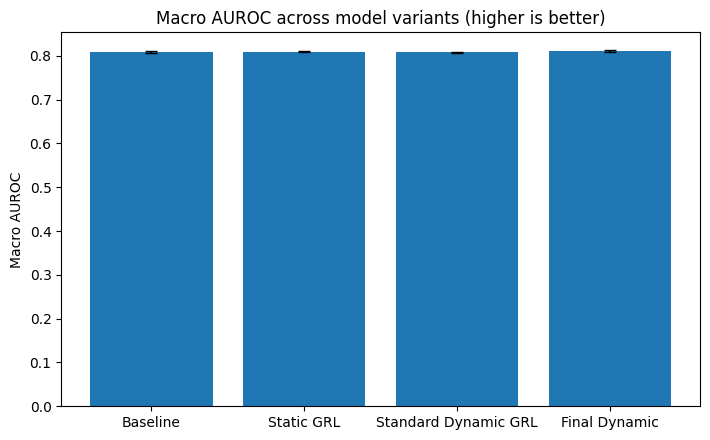

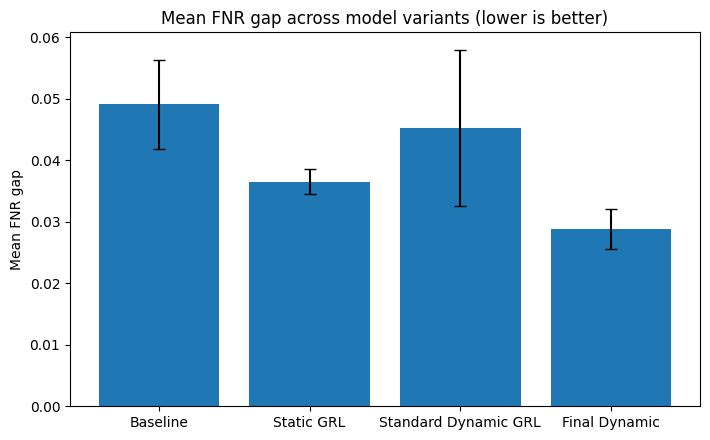

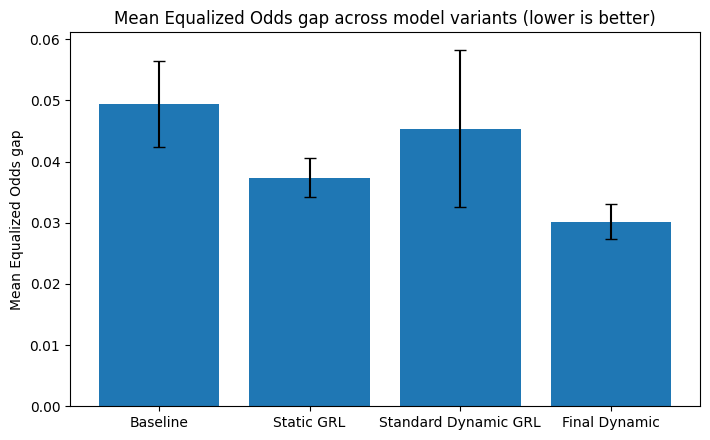

Saved figures to: /Users/shuu/Desktop/Msc Program/figures


In [6]:
# ------------------------------------------------------------------
# Optional: concise figures for Chapters 4 and 5
# ------------------------------------------------------------------
def plot_metric(metric, ylabel, lower_is_better, filename):
    plot_df = main_summary[["model", f"{metric}_mean", f"{metric}_std"]].copy()
    plot_df = plot_df.set_index("model").reindex(list(MODEL_SPECS.keys())).reset_index()
    plt.figure(figsize=(7.2, 4.5))
    plt.bar(plot_df["model"], plot_df[f"{metric}_mean"], yerr=plot_df[f"{metric}_std"], capsize=4)
    plt.ylabel(ylabel)
    plt.xlabel("")
    suffix = "lower is better" if lower_is_better else "higher is better"
    plt.title(f"{ylabel} across model variants ({suffix})")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_metric("macro_AUROC", "Macro AUROC", False, "final_analysis_macro_auroc_mean_std.png")
plot_metric("mean_FNR_gap", "Mean FNR gap", True, "final_analysis_mean_fnr_gap_mean_std.png")
plot_metric("mean_Equalized_Odds_gap", "Mean Equalized Odds gap", True, "final_analysis_mean_eo_gap_mean_std.png")

print("Saved figures to:", FIGURES_DIR.resolve())


In [7]:
# ------------------------------------------------------------------
# Final Dynamic vs Static GRL: concise dissertation-ready comparison
# ------------------------------------------------------------------
comparison_metrics = [
    "macro_AUROC",
    "macro_AUPRC",
    "mean_FNR_gap",
    "mean_FPR_gap",
    "mean_Equalized_Odds_gap",
    "mean_Worst_group_Recall",
    "mean_AUROC_gap",
]

mean_by_model = overall_seed.groupby("model")[comparison_metrics].mean()
final_vs_static = pd.DataFrame({
    "Static GRL": mean_by_model.loc["Static GRL"],
    "Final Dynamic": mean_by_model.loc["Final Dynamic"],
})
final_vs_static["Final Dynamic - Static GRL"] = (
    final_vs_static["Final Dynamic"] - final_vs_static["Static GRL"]
)
final_vs_static.index.name = "metric"
final_vs_static.to_csv(
    RESULTS_DIR / "final_analysis_final_dynamic_vs_static_grl.csv"
)

print("Final Dynamic vs Static GRL")
display(final_vs_static)

if RUN_BOOTSTRAP:
    print("Paired 95% CIs: Final Dynamic - Static GRL")
    display(
        paired_difference_ci[
            paired_difference_ci["comparison"] == "Final Dynamic - Static GRL"
        ].reset_index(drop=True)
    )


Final Dynamic vs Static GRL


,Static GRL,Final Dynamic,Final Dynamic - Static GRL
metric,,,
macro_AUROC,0.809820,0.811339,0.001519
macro_AUPRC,0.306702,0.311405,0.004703
mean_FNR_gap,0.036504,0.028795,-0.007709
mean_FPR_gap,0.013985,0.010229,-0.003756
mean_Equalized_Odds_gap,0.037381,0.030151,-0.007229
mean_Worst_group_Recall,0.451843,0.462229,0.010386
mean_AUROC_gap,0.012374,0.012665,0.000291


Paired 95% CIs: Final Dynamic - Static GRL


,comparison,metric,point_difference_candidate_minus_reference,ci_level,ci_lower,ci_upper,zero_in_ci,n_bootstrap,resampling_unit
0,Final Dynamic - Static GRL,macro_AUROC,0.001519,0.95,-0.000405,0.003493,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
1,Final Dynamic - Static GRL,macro_AUPRC,0.004703,0.95,0.001017,0.008337,False,10000,"Paired Patient ID cluster bootstrap, stratifie..."
2,Final Dynamic - Static GRL,mean_FNR_gap,-0.007709,0.95,-0.017322,0.007217,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
3,Final Dynamic - Static GRL,mean_FPR_gap,-0.003756,0.95,-0.006749,0.001675,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
4,Final Dynamic - Static GRL,mean_Equalized_Odds_gap,-0.007229,0.95,-0.017160,0.006462,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
5,Final Dynamic - Static GRL,mean_Worst_group_Recall,0.010386,0.95,0.000296,0.018080,False,10000,"Paired Patient ID cluster bootstrap, stratifie..."
6,Final Dynamic - Static GRL,mean_AUROC_gap,0.000291,0.95,-0.003579,0.003912,True,10000,"Paired Patient ID cluster bootstrap, stratifie..."
